In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Settings
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

## Importing the dataset

In [2]:
data = pd.read_csv(r"C:\Users\HP\Documents\Data journey\Internflare\Datasets\cleaned_internflare.csv")
data.head()

,Partner_ID,Partner_Name,Intern_ID,Intern_Name,Intern_Assigned_To,Service_Type,Fee_Charged,Payment_Status,Country,Start_Date,End_Date,Intern_Hours,Feedback_Rating
0,P001,CloudSoft,I1000,Nathan Stevens,CloudSoft,Branding,799,Paid,Nigeria,2025-04-02,2025-08-28,398.0,3.0
1,P005,CloudSoft,I1001,Mario Alvarez,CloudSoft,Masterclass,1621,Pending,United States,2024-08-26,2025-06-25,91.0,2.0
2,P003,Alpha Tech,I1002,Shane Fuller,Alpha Tech,Masterclass,1718,Failed,Canada,2025-05-18,2025-12-15,88.0,4.0
3,P008,EcoTrans,I1003,Nicholas West,EcoTrans,Analytics,995,Paid,Canada,2025-04-24,2025-11-22,482.5,4.0
4,P004,Betta Ltd.,I1004,Matthew Harper,Betta Ltd.,Web Dev,1568,Failed,Nigeria,2023-10-06,2025-07-21,686.0,5.0


## Exploratory Data Analysis

- Count unique partners and interns
- Calculate total revenue
- Analyze revenue by service type
- Identify top 5 countries by number of partners
- Compute average feedback rating by service type
- Analyze correlation between hours worked and feedback rating
- Analyze revenue trends over time (monthly or quarterly)
- Identify services with highest revenue and strongest growth
- Analyze partner churn (one-time vs repeat partners)

#### Unique partners and interns

In [3]:
partners = data['Partner_Name'].nunique()
interns = data['Intern_Name'].nunique()

print(f'There are a total of {partners} partners and {interns} interns in the dataset.')

There are a total of 10 partners and 2799 interns in the dataset.


#### Total Revenue

Revenue will be divided into 3 based on payment status

- Actual Revenue - Payment status is 'Paid'
- Outstanding Revenue - Payment status is not 'Paid'
- Total Revenue = Actual + Outstanding

In [4]:
actual_rev = data[data['Payment_Status'] == 'Paid']['Fee_Charged'].sum()
outstanding_rev =  data[data['Payment_Status'] != 'Paid']['Fee_Charged'].sum()
total_rev = data['Fee_Charged'].sum()

print(f'Total Revenue = ${total_rev}')
print(f'Actual Revenue = ${actual_rev}')
print(f'Outstanding Revenue = ${outstanding_rev}')

Total Revenue = $3172192
Actual Revenue = $628455
Outstanding Revenue = $2543737


#### Revenue By Service Type

In [5]:
service_revenue = data.groupby('Service_Type')['Fee_Charged'].sum().sort_values().reset_index()
service_revenue

,Service_Type,Fee_Charged
0,Web Dev,369743
1,Analytics,375667
2,Cloud Migration,384797
3,Social Media,401627
4,Growth Strategy,402011
5,SEO,406286
6,Masterclass,411047
7,Branding,421014


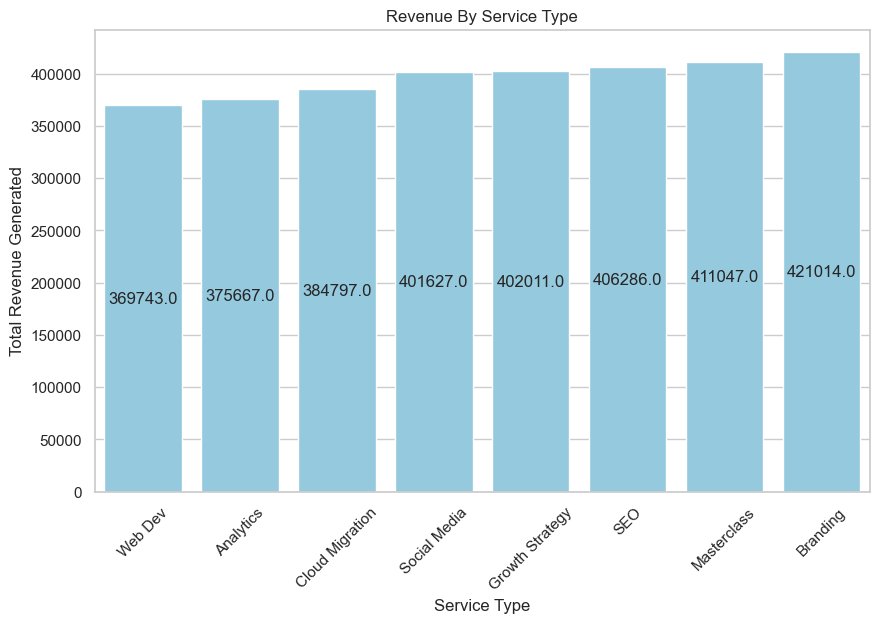

In [7]:
fig, ax = plt.subplots()

sns.barplot(service_revenue, x= 'Service_Type', y = 'Fee_Charged', color = 'skyblue')

for p in plt.gca().patches:
    plt.text(p.get_x() + p.get_width()/2, p.get_height()/2, 
             str(p.get_height()),
             ha='center',
             va='center')
    
plt.title('Revenue By Service Type')
plt.xlabel('Service Type')
plt.ylabel('Total Revenue Generated')
plt.xticks(rotation= 45)



plt.savefig('Revenue By Service Type', dpi = 300)
plt.show()

### Insight

Branding Service generated the highest revenue of just over USD420000 whilst Web Dev generated the least revenue just above USD369000

#### Top 5 Countries By Number of Partners

In [8]:
country_partner = data.groupby('Country')['Partner_Name'].count().sort_values().reset_index()

country_partner.rename(columns={'Partner_Name': 'Total_Partners'}, inplace = True)

#top 5 countries
country_partner.head(5)

,Country,Total_Partners
0,Germany,304
1,Canada,576
2,United States,595
3,United Kingdom,635
4,Nigeria,890


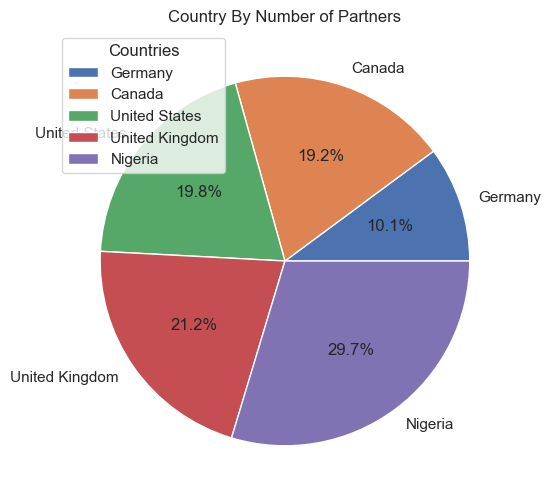

In [9]:
fig, ax = plt.subplots()

ax.pie(country_partner['Total_Partners'], labels=country_partner['Country'], autopct='%1.1f%%')
ax.set_title('Country By Number of Partners')
ax.legend(loc = 'best', title='Countries')


plt.savefig("Country By Number of Partners", dpi = 300)
plt.show()

### Insight

Nigeria has the most Partners with almost 30% of Internflare's Partners being Nigerian organizations and just over 21% from the United Kingdom

#### Average Feedback Rating by Service Type

In [10]:
service_rating = data.groupby('Service_Type')['Feedback_Rating'].mean().round(2).sort_values().reset_index()

service_rating

,Service_Type,Feedback_Rating
0,Social Media,2.83
1,Branding,2.84
2,SEO,2.85
3,Web Dev,2.91
4,Analytics,2.97
5,Masterclass,2.97
6,Growth Strategy,2.98
7,Cloud Migration,3.01


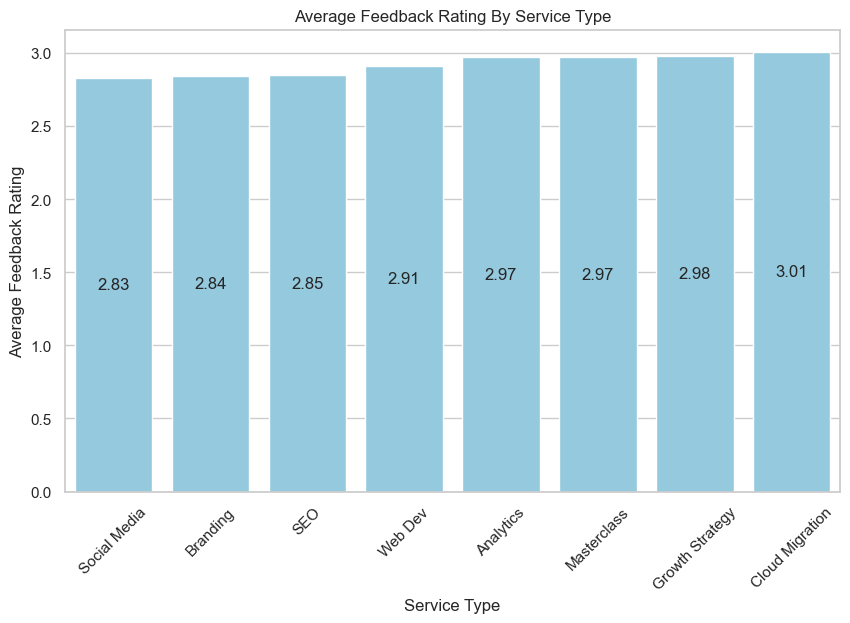

In [11]:
fig, ax = plt.subplots()

sns.barplot(service_rating, x = 'Service_Type', y = 'Feedback_Rating', color = 'skyblue')

for p in plt.gca().patches:
    plt.text(p.get_x() + p.get_width()/2, p.get_height()/2, 
             str(p.get_height()),
             ha='center',
             va='center')
    
plt.title('Average Feedback Rating By Service Type')
plt.xlabel('Service Type')
plt.ylabel('Average Feedback Rating')
plt.xticks(rotation = 45)


plt.savefig('Average Feedback Rating By Service Type', dpi = 300)
plt.show()

#### Correlation between hours worked and feedback rating

In [12]:
data[['Intern_Hours', 'Feedback_Rating']].corr()

,Intern_Hours,Feedback_Rating
Intern_Hours,1.000000,-0.053968
Feedback_Rating,-0.053968,1.000000


### Insight

No correlation between these 2 variables

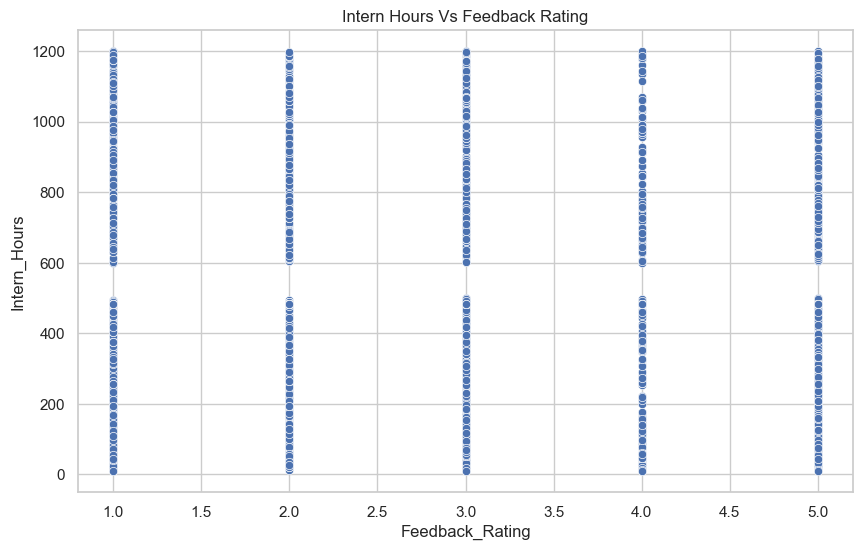

In [13]:
fig, ax = plt.subplots()

sns.scatterplot(x= data['Feedback_Rating'], y=data['Intern_Hours'])
plt.title('Intern Hours Vs Feedback Rating')

plt.savefig('Intern Hours Vs Feedback Rating', dpi=300)
plt.show()

### Insight

No clear relationship or correlation between Intern Hours and their feedback ratings

#### Revenue trends overtime

Let's convert the date columns to date datatype

In [14]:
data['Start_Date'] = pd.to_datetime(data['Start_Date'])

In [15]:
data['End_Date'] = pd.to_datetime(data['End_Date'])

In [16]:
trend_data = data[['Start_Date', 'Fee_Charged']]

trend_data.set_index('Start_Date', inplace=True)
trend_data

,Fee_Charged
Start_Date,
2025-04-02,799
2024-08-26,1621
2025-05-18,1718
2025-04-24,995
2023-10-06,1568
...,...
2024-01-19,1329
2024-04-09,1558
2023-10-23,1288


C:\Users\HP\AppData\Local\Temp\ipykernel_19416\429697249.py:3: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  trend_data.resample('Q').mean().plot(ax=ax)


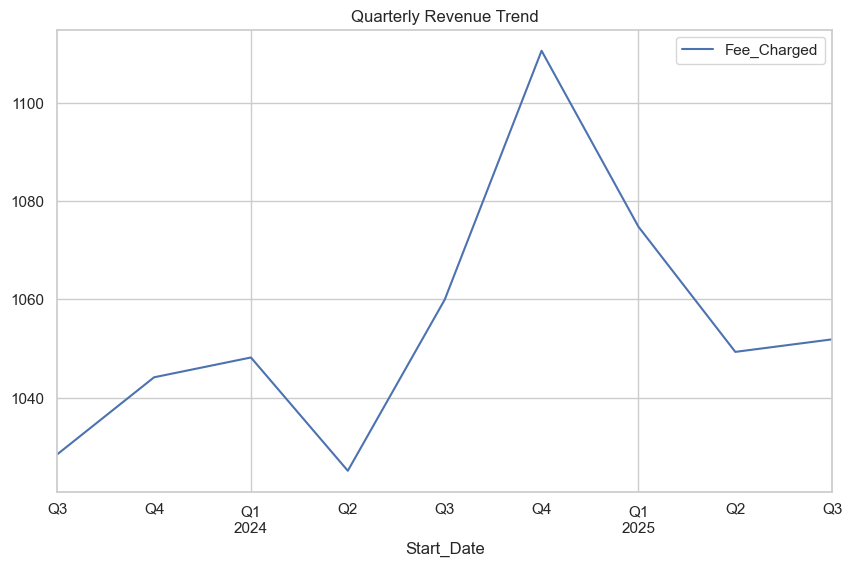

In [17]:
fig, ax = plt.subplots()

trend_data.resample('Q').mean().plot(ax=ax)
plt.title('Quarterly Revenue Trend')

plt.savefig('Quarterly Revenue Trend', dpi=300)
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_19416\3223963324.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  trend_data.resample('M').mean().plot(ax=ax)


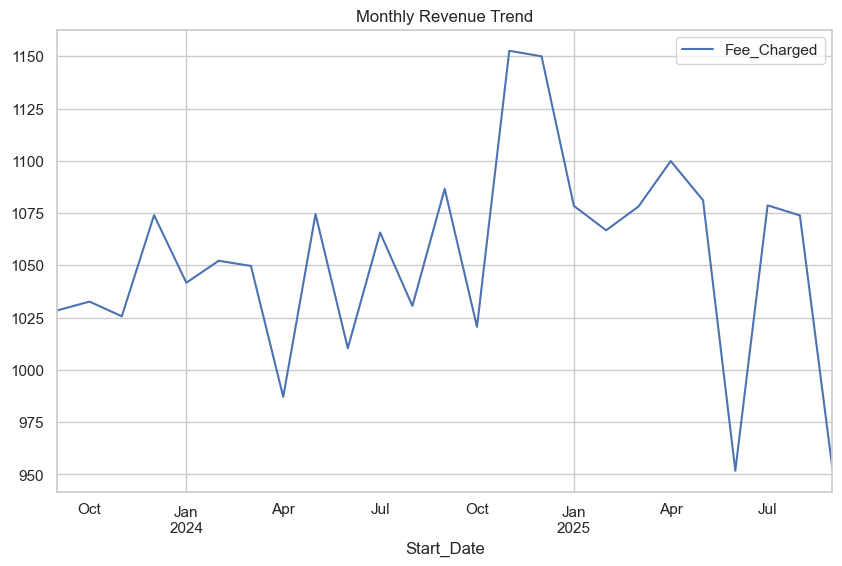

In [18]:
fig, ax = plt.subplots()

trend_data.resample('M').mean().plot(ax=ax)
plt.title('Monthly Revenue Trend')

plt.savefig('Monthly Revenue Trend', dpi=300)
plt.show()

## Insight

A steady increase in revenue from 2023 to 2025, but there has been a decline in revenue from the 1st quarter of 2025

#### Services with highest revenue and strongest growth

In [19]:
service_rev = data.groupby('Service_Type')['Fee_Charged'].sum().sort_values(ascending=False).reset_index()

service_rev.set_index('Service_Type', inplace=True)

service_rev

,Fee_Charged
Service_Type,
Branding,421014
Masterclass,411047
SEO,406286
Growth Strategy,402011
Social Media,401627
Cloud Migration,384797
Analytics,375667
Web Dev,369743


In [20]:
service_growth = data.groupby(['Service_Type',
                               data['Start_Date'].dt.to_period('Q')]).size().reset_index(name = 'Count')

service_growth

,Service_Type,Start_Date,Count
0,Analytics,2023Q3,3
1,Analytics,2023Q4,39
2,Analytics,2024Q1,43
3,Analytics,2024Q2,32
4,Analytics,2024Q3,58
...,...,...,...
67,Web Dev,2024Q3,29
68,Web Dev,2024Q4,46
69,Web Dev,2025Q1,47
70,Web Dev,2025Q2,46


In [21]:
service_growth['Start_Date'] = service_growth['Start_Date'].dt.to_timestamp()

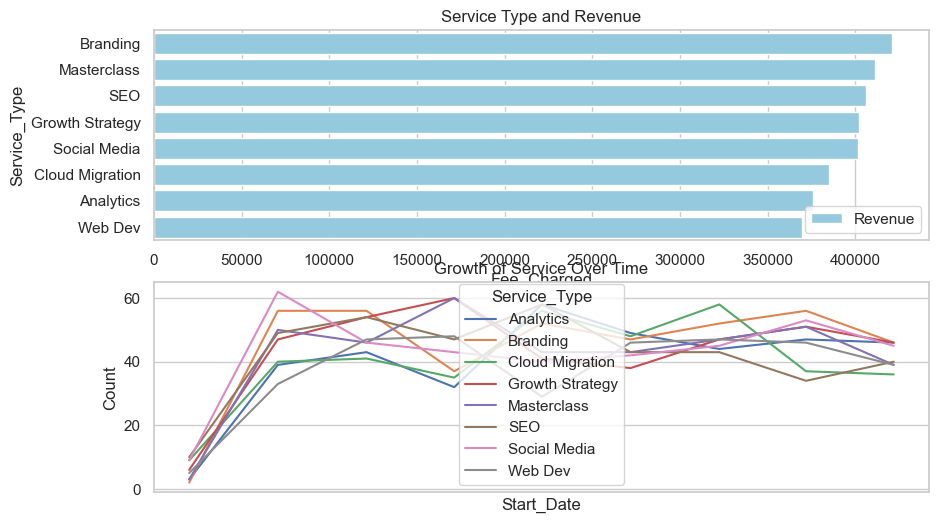

In [22]:
fig, ax = plt.subplots(2, 1)

sns.barplot(y=service_rev.index, x=service_rev['Fee_Charged'], label='Revenue', color='skyblue', orient='h', ax= ax[0])
plt.xticks(ticks=None)
ax[0].set_title('Service Type and Revenue')

sns.lineplot(data=service_growth, x= 'Start_Date', y='Count', hue='Service_Type', ax=ax[1])
plt.xticks([])
ax[1].set_title('Growth of Service Over Time')

plt.savefig('Service Type Revenue and Growth Over Time', dpi=300)
plt.show()

### Insight

Overtime(Quarterly basis), Services such as Cloud Migration, SEO & Web Dev have not been doing well, whilst services such as Analytics, Branding and Social Media have been growing this is irrespective of the total revenue they bring in

#### Partner Churn (One time Vs Repeat)

In [23]:
partner_counts = data['Partner_Name'].value_counts()

partner_counts

Partner_Name
InfinitX        333
Betta Ltd.      327
Nova Systems    314
CloudSoft       309
Green Energy    306
TechBridge      301
Skyline Inc.    297
EcoTrans        286
Alpha Tech      272
DataCore        255
Name: count, dtype: int64

There are no one time partners

In [24]:
churn_rate = partner_counts/len(partner_counts)

churn_rate.reset_index(name='Churn_Rate')

,Partner_Name,Churn_Rate
0,InfinitX,33.3
1,Betta Ltd.,32.7
2,Nova Systems,31.4
3,CloudSoft,30.9
4,Green Energy,30.6
5,TechBridge,30.1
6,Skyline Inc.,29.7
7,EcoTrans,28.6
8,Alpha Tech,27.2
9,DataCore,25.5


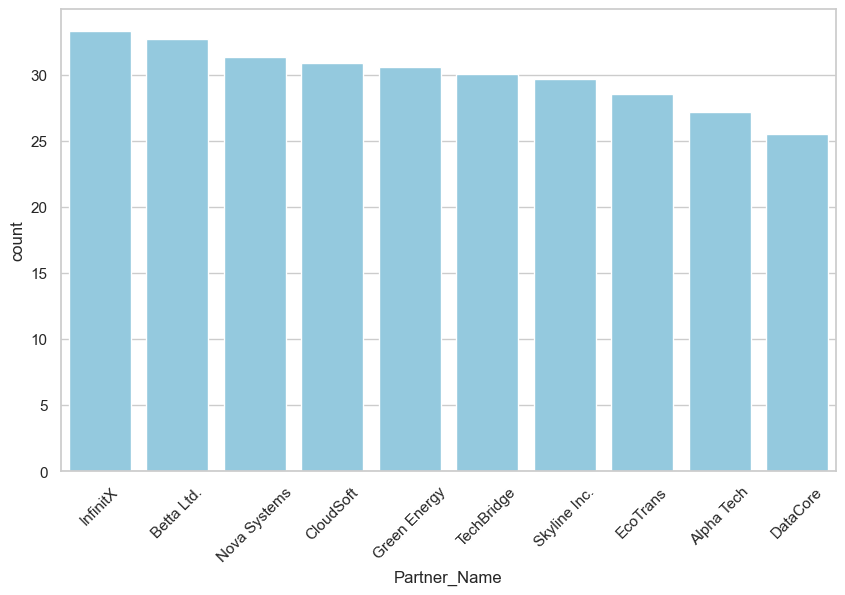

In [25]:
fig, ax = plt.subplots()

sns.barplot(churn_rate, color='skyblue')
plt.xticks(rotation = 45)

plt.savefig('Partner Churn Rate', dpi=300)
plt.show()

#### Payment Status Distribution

In [26]:
payment_status = data['Payment_Status'].value_counts().reset_index()

payment_status

,Payment_Status,count
0,Pending,1228
1,Failed,1170
2,Paid,602


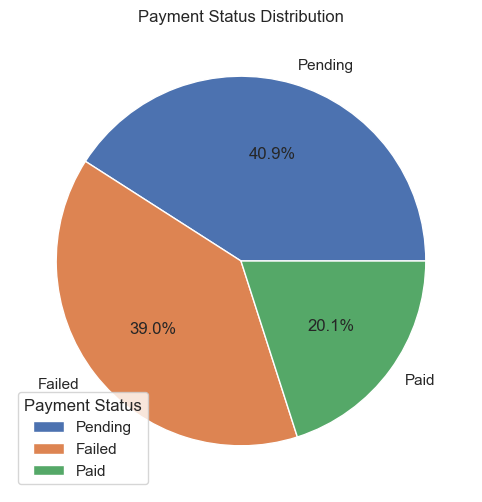

In [27]:
fig, ax = plt.subplots()

ax.pie(payment_status['count'], labels=payment_status['Payment_Status'], autopct='%1.1f%%')
ax.set_title('Payment Status Distribution')
ax.legend(loc = 'best', title='Payment Status')


plt.savefig("Payment Status Distribution", dpi = 300)
plt.show()

### Insight

Most of the payments are pending (40.9%) and less that 25% pf payments have actually reflected as paid. The mode of payment needs to be addresed across different nations

#### Feedback Rating Distribution

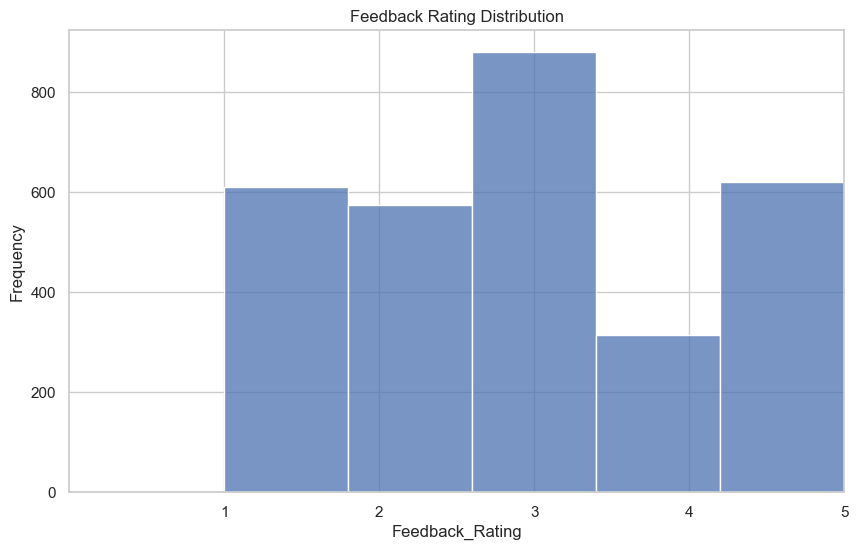

In [28]:
fig, ax = plt.subplots()
sns.histplot(data['Feedback_Rating'], bins=5)
plt.xlim(0, 5)
plt.xticks(np.arange(1, 6, 1))
plt.ylabel('Frequency')
plt.title('Feedback Rating Distribution')

plt.savefig("Feedback Rating Distribution", dpi = 300)
plt.show()

### Insight

Interns are mostly rated average in their service provided